<a href="https://colab.research.google.com/github/catdavis25/Student-Success-Analysis/blob/main/CapstoneProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from math import exp
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import scale
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, r2_score
import seaborn as sns

In [ ]:
path = kagglehub.dataset_download("nikhil7280/student-performance-multiple-linear-regression")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/nikhil7280/student-performance-multiple-linear-regression/versions/1


In [ ]:
df = pd.read_csv(path + "/Student_Performance.csv")
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [ ]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [ ]:
df.duplicated().sum()

127

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

0

In [ ]:
df.isnull().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


In [ ]:
df.isna().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


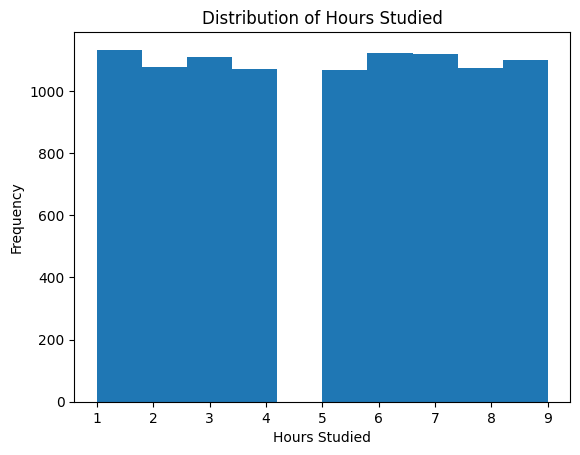

In [ ]:
plt.hist(df['Hours Studied'])
plt.title('Distribution of Hours Studied')
plt.xlabel('Hours Studied')
plt.ylabel('Frequency')
plt.show()

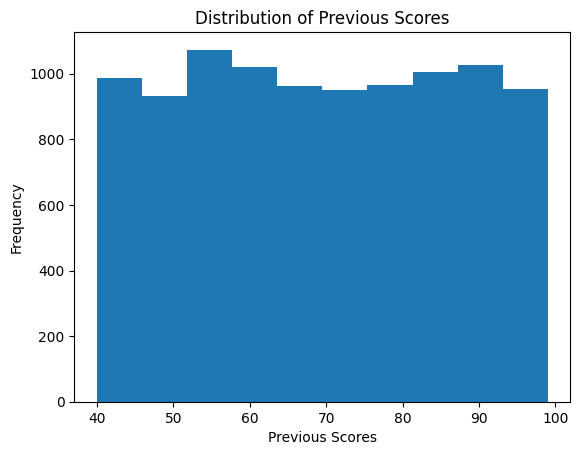

In [ ]:
plt.hist(df['Previous Scores'])
plt.title('Distribution of Previous Scores')
plt.xlabel('Previous Scores')
plt.ylabel('Frequency')
plt.show()

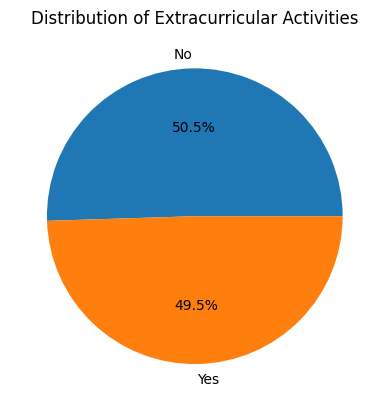

In [ ]:
plt.pie(df['Extracurricular Activities'].value_counts(), labels=df['Extracurricular Activities'].value_counts().index, autopct='%1.1f%%')
plt.title('Distribution of Extracurricular Activities')
plt.show()

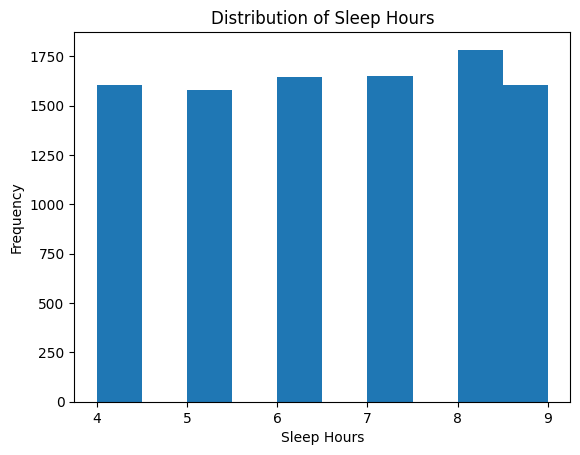

In [ ]:
plt.hist(df['Sleep Hours'])
plt.title('Distribution of Sleep Hours')
plt.xlabel('Sleep Hours')
plt.ylabel('Frequency')
plt.show()

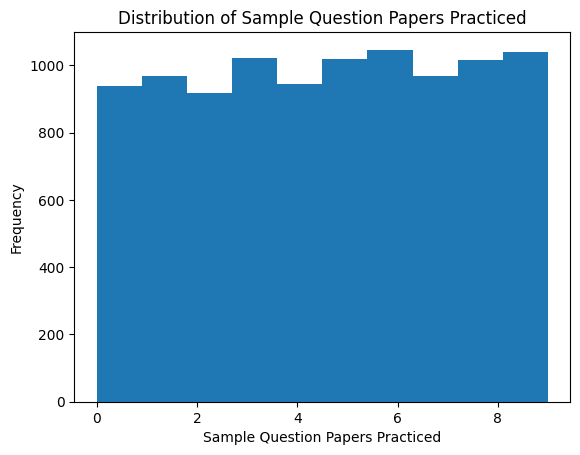

In [ ]:
plt.hist(df['Sample Question Papers Practiced'])
plt.title('Distribution of Sample Question Papers Practiced')
plt.xlabel('Sample Question Papers Practiced')
plt.ylabel('Frequency')
plt.show()

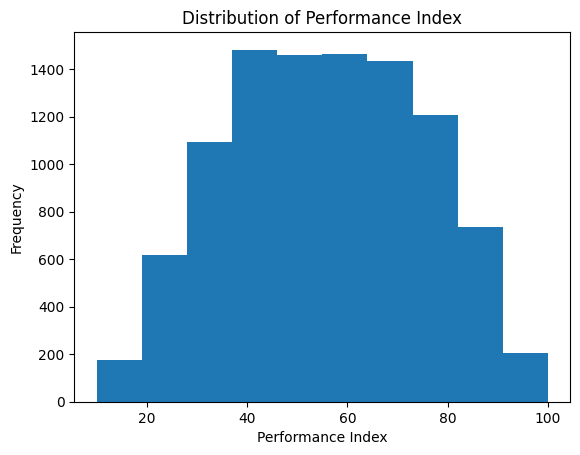

In [ ]:
plt.hist(df['Performance Index'])
plt.title('Distribution of Performance Index')
plt.xlabel('Performance Index')
plt.ylabel('Frequency')
plt.show()

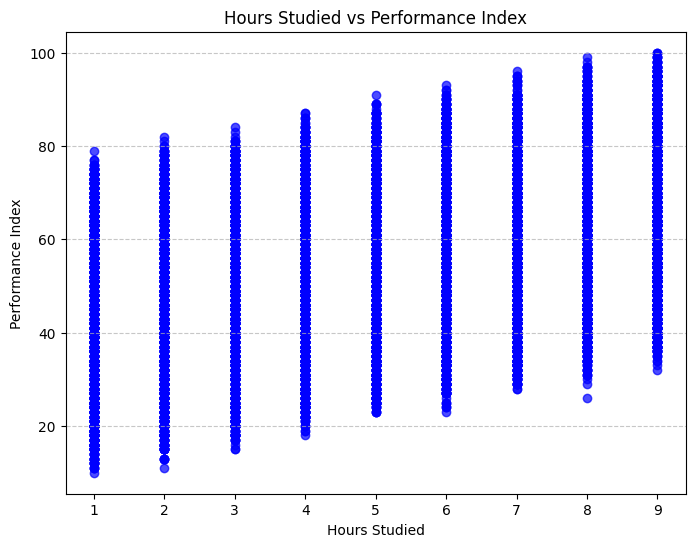

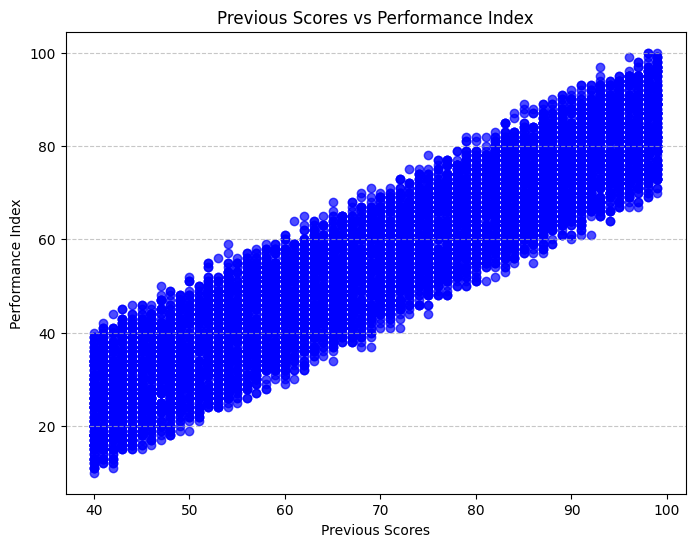

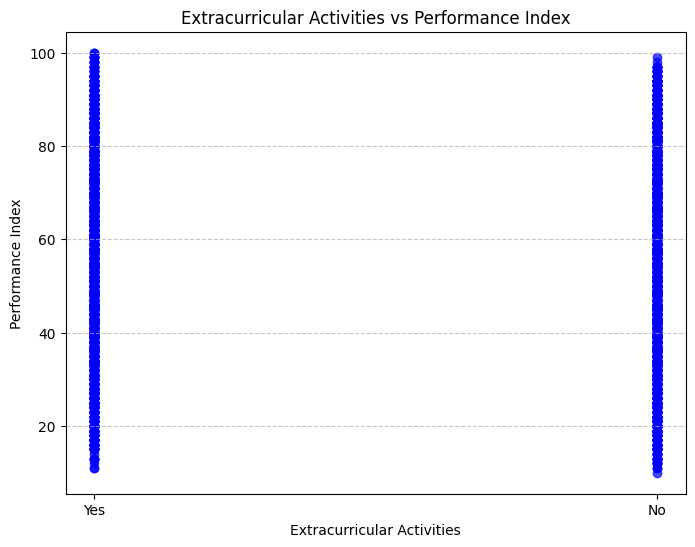

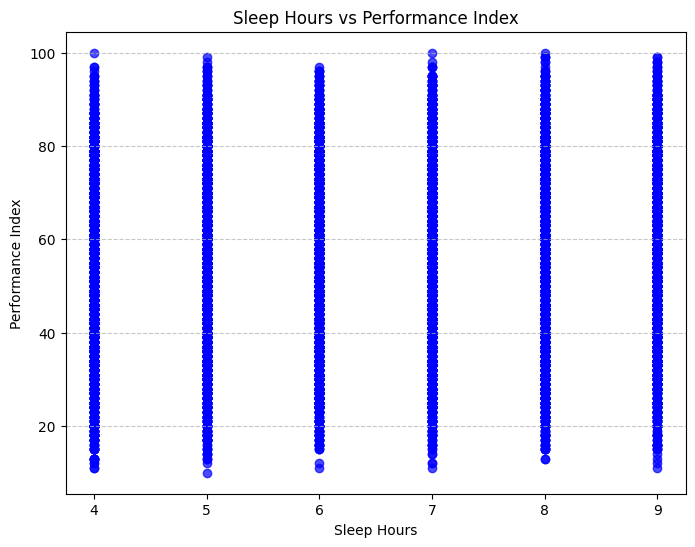

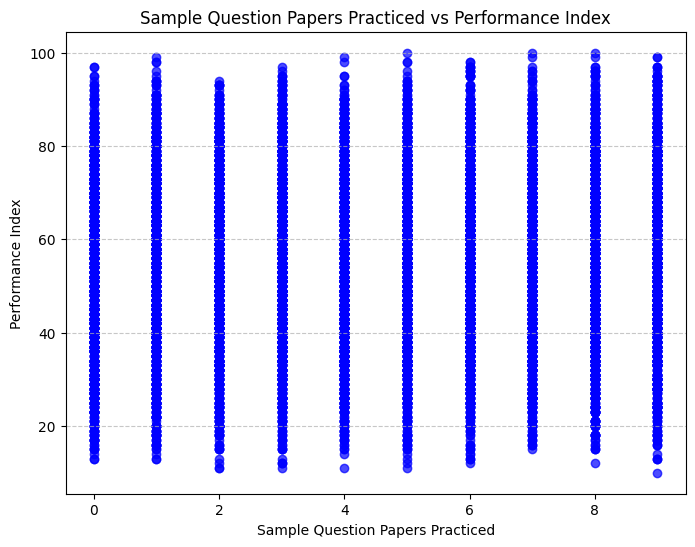

In [ ]:
columns = df.columns.tolist()
columns.remove("Performance Index")

for col in columns:

    plt.figure(figsize=(8, 6))
    plt.scatter(df[col], df["Performance Index"], color='blue', alpha=0.7)
    plt.xlabel(col)
    plt.ylabel(f"Performance Index")
    plt.title(f"{col} vs Performance Index")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

In [ ]:
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'Yes': 1, 'No': 0})
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


In [ ]:
Q1 = df['Hours Studied'].quantile(0.25)
Q3 = df['Hours Studied'].quantile(0.75)
IQR = Q3 - Q1

threshold = 1.5
outliers = df[(df['Hours Studied'] < Q1 - threshold * IQR) | (df['Hours Studied'] > Q3 + threshold * IQR)]
df = df.drop(outliers.index)

num_outliers = len(outliers)
print(f"Number of outliers removed: {num_outliers}")

Number of outliers removed: 0


In [ ]:
Q1 = df['Previous Scores'].quantile(0.25)
Q3 = df['Previous Scores'].quantile(0.75)
IQR = Q3 - Q1

threshold = 1.5
outliers = df[(df['Previous Scores'] < Q1 - threshold * IQR) | (df['Previous Scores'] > Q3 + threshold * IQR)]
df = df.drop(outliers.index)

num_outliers = len(outliers)
print(f"Number of outliers removed: {num_outliers}")

Number of outliers removed: 0


In [ ]:
Q1 = df['Sleep Hours'].quantile(0.25)
Q3 = df['Sleep Hours'].quantile(0.75)
IQR = Q3 - Q1

threshold = 1.5
outliers = df[(df['Sleep Hours'] < Q1 - threshold * IQR) | (df['Sleep Hours'] > Q3 + threshold * IQR)]
df = df.drop(outliers.index)

num_outliers = len(outliers)
print(f"Number of outliers removed: {num_outliers}")

Number of outliers removed: 0


In [ ]:
Q1 = df['Sample Question Papers Practiced'].quantile(0.25)
Q3 = df['Sample Question Papers Practiced'].quantile(0.75)
IQR = Q3 - Q1

threshold = 1.5
outliers = df[(df['Sample Question Papers Practiced'] < Q1 - threshold * IQR) | (df['Sample Question Papers Practiced'] > Q3 + threshold * IQR)]
df = df.drop(outliers.index)

num_outliers = len(outliers)
print(f"Number of outliers removed: {num_outliers}")

Number of outliers removed: 0


In [ ]:
Q1 = df['Sample Question Papers Practiced'].quantile(0.25)
Q3 = df['Sample Question Papers Practiced'].quantile(0.75)
IQR = Q3 - Q1

threshold = 1.5
outliers = df[(df['Sample Question Papers Practiced'] < Q1 - threshold * IQR) | (df['Sample Question Papers Practiced'] > Q3 + threshold * IQR)]
df = df.drop(outliers.index)

num_outliers = len(outliers)
print(f"Number of outliers removed: {num_outliers}")

Number of outliers removed: 0


In [ ]:
Q1 = df['Performance Index'].quantile(0.25)
Q3 = df['Performance Index'].quantile(0.75)
IQR = Q3 - Q1

threshold = 1.5
outliers = df[(df['Performance Index'] < Q1 - threshold * IQR) | (df['Performance Index'] > Q3 + threshold * IQR)]
df = df.drop(outliers.index)

num_outliers = len(outliers)
print(f"Number of outliers removed: {num_outliers}")

Number of outliers removed: 0


<Axes: >

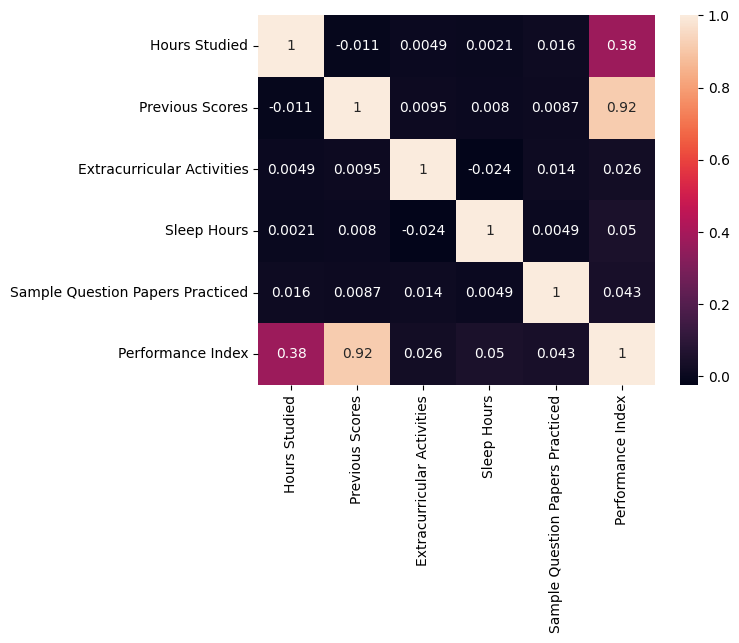

In [ ]:
sns.heatmap(df.corr(), annot=True)

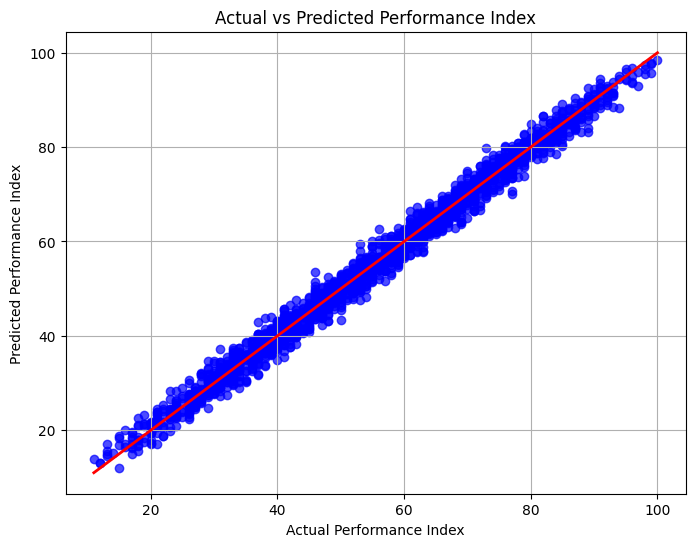

R^2: 98.84301209927054%


In [ ]:
X = df.drop(columns=["Performance Index"])
y = df["Performance Index"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color="blue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", lw=2)
plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title("Actual vs Predicted Performance Index")
plt.grid(True)
plt.show()

accuracy = r2_score(y_test, y_pred)
print(f"R^2: {accuracy*100}%")